# E2 — Transformer Fine-tuning (RoBERTa)
**Project:** Social Media Sentiment & Hate Detection  
**Experiment:** E2 — Transformer Fine-tuning  
**Dataset:** [TweetEval](https://huggingface.co/datasets/cardiffnlp/tweet_eval) (`sentiment` and `hate` subsets)

---

## Overview

This notebook implements **Experiment 2 (E2)**: fine-tuning domain-specific RoBERTa checkpoints on two independent NLP tasks.

| Task | Pretrained checkpoint | Labels | Train size | Epochs |
|---|---|---|---|---|
| Sentiment Analysis | `cardiffnlp/twitter-roberta-base-sentiment-latest` | 3-class (negative / neutral / positive) | 45,615 | 5 |
| Hate Speech Detection | `cardiffnlp/twitter-roberta-base-hate-latest` | 2-class (non-hate / hate) | 9,000 | 3 |

**Why these checkpoints?**  
Both models were pre-trained on Twitter data — the same domain as TweetEval. This makes them significantly stronger starting points than plain `bert-base-uncased` or `roberta-base`, which were pre-trained on formal English text and lack exposure to tweet-specific language patterns (abbreviations, slang, hashtags, emoji, `@user` mentions).

**Design decisions:**
- **Self-contained:** re-loads data from HuggingFace; no dependency on `data_analysis.ipynb` or `baseline_model.ipynb`.
- **Memory management:** after the sentiment model is saved and archived, all its objects are explicitly deleted and CUDA cache is cleared before loading the hate model.
- **Evaluation metric:** macro-F1 (primary); accuracy also reported. Macro-F1 is used as the `metric_for_best_model` in `TrainingArguments` so the best checkpoint is selected by F1, not loss.
- **`load_best_model_at_end=True`:** the checkpoint with the highest validation macro-F1 is automatically restored at the end of training.

**Notebook structure:**
1. Imports & Constants  
2. Device Setup & Seed  
3. Data Loading & Preprocessing  
4. `TweetDataset` Class  
5. Sentiment Model — Fine-tuning  
6. Sentiment Model — Evaluation & Saving  
7. Memory Cleanup  
8. Hate Model — Fine-tuning  
9. Hate Model — Evaluation & Saving  
10. E1 vs E2 — Comparative Results Table


## 1. Imports & Constants

### 1.1 Library Imports


In [1]:
# Python std
import os
import gc
import re
import random

# Data/numeric and Visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Pytorch
import torch
from torch.utils.data import Dataset, DataLoader

# Huggingface
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, set_seed

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix, ConfusionMatrixDisplay

### 1.2 Hyperparameter Constants

All training hyperparameters are centralised here for easy adjustment.

| Constant | Value | Purpose |
|---|---|---|
| `SEED` | 42 | Global reproducibility seed |
| `LR` | 2e-5 | Learning rate — standard for RoBERTa fine-tuning |
| `SENTI_EPOCHS` | 5 | More epochs for the harder 3-class task |
| `HATE_EPOCHS` | 3 | Fewer epochs; 2-class task converges faster |
| `BATCH_SIZE` | 128 | Per-device batch size |
| `MAX_LENGTH` | 128 | Token sequence length (truncation/padding target) |
| `WARMUP_RATIO` | 0.06 | Fraction of total steps used for LR warm-up |
| `WEIGHT_DECAY` | 0.01 | L2 regularisation applied to all non-bias parameters |
| `SENTI_MODEL_NAME` | `twitter-roberta-base-sentiment-latest` | Twitter-domain checkpoint for sentiment |
| `HATE_MODEL_NAME` | `twitter-roberta-base-hate-latest` | Twitter-domain checkpoint for hate |

> **Why `max_length=128`?**  
> EDA showed sentiment tweets max out at ~35 words; hate tweets reach ~90–93 words. At ~1.3 tokens per word on average for Twitter text, 128 tokens safely covers the vast majority of tweets in both tasks, with only a small minority of hate tweets risking minor truncation (documented as a limitation).


In [2]:
# Constants
SEED = 42
LR = 2e-5
HATE_EPOCHS = 3
SENTI_EPOCHS = 5
BATCH_SIZE = 128
MAX_LENGTH = 128
WARMUP_RATIO = 0.06
WEIGHT_DECAY = 0.01
HATE_MODEL_NAME = 'cardiffnlp/twitter-roberta-base-hate-latest'
SENTI_MODEL_NAME = 'cardiffnlp/twitter-roberta-base-sentiment-latest'

## 2. Device Setup & Global Seed

### 2.1 Device Detection

PyTorch automatically selects the best available compute device:  
`CUDA` (NVIDIA GPU) → `MPS` (Apple Silicon) → `CPU`.  

In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
DEVICE

device(type='cuda')

### 2.2 Global Seed

`set_all_seeds` sets seeds across Python's `random`, NumPy, PyTorch (CPU + all CUDA devices), and the HuggingFace `Trainer` — ensuring fully reproducible training runs.


In [4]:
def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    set_seed(seed)

set_all_seeds(SEED)

## 3. Data Loading & Preprocessing

### 3.1 Load Datasets

Both TweetEval subsets are loaded from HuggingFace and converted to pandas DataFrames via `set_format(type="pandas")`.

> **Hate dataset empty-row handling:**  
> EDA identified 2 empty rows in hate train and 1 in hate val. These are dropped here via regex replacement to `NaN` followed by `dropna`.


In [7]:
ds_senti = load_dataset("cardiffnlp/tweet_eval", "sentiment")
ds_hate = load_dataset("cardiffnlp/tweet_eval", "hate")

ds_senti.set_format(type="pandas")
senti_train = ds_senti["train"][:]
senti_val = ds_senti["validation"][:]
senti_test = ds_senti["test"][:]

ds_hate.set_format(type="pandas")
hate_train = ds_hate["train"][:]
hate_val = ds_hate["validation"][:]
hate_test = ds_hate["test"][:]

In [8]:
# Dropping Null values from hate train and val splits which was observed during EDA
hate_train = hate_train.replace(r'^\s*$', np.nan, regex=True).dropna(subset=['text']).reset_index(drop=True)
hate_val = hate_val.replace(r'^\s*$', np.nan, regex=True).dropna(subset=['text']).reset_index(drop=True)

### 3.2 Text Preprocessing — `clean_text`

The same `clean_text` function from `baseline_model.ipynb` is re-declared here (this notebook is self-contained).

**Pipeline:**
1. Lowercase
2. Mention anonymisation — `@username` → `@user` (negative lookahead skips already-anonymised tokens)
3. URL removal
4. Hashtag normalisation — strip `#`, keep text
5. Whitespace normalisation

> **Note:** Slurs are intentionally **not** removed — they carry direct hate signal.


In [9]:
def clean_text(text):

    # 1. Lowercase
    lower_text = text.lower()

    # 2. User anonymization
    mention_pattern = r'@(?!user)\w+'
    anony_text = re.sub(mention_pattern, ' @user', lower_text)

    # 3. URL Removal
    no_url_text = re.sub(r'https?://\S+', '', anony_text)
    
    # 4. Stripping hashtag but keeping hastag content
    removed_hash_text = no_url_text.replace("#", "")
    
    # 5. Normalize whitespace(strip + collapse internal spaces)
    stripped_text = removed_hash_text.strip()
    cleaned_text = " ".join(stripped_text.split())

    return cleaned_text

### 3.3 Apply Preprocessing & Verify Shapes

`clean_text` is applied to all six splits. A new `clean_text` column is added while the original `text` column is preserved.  
Shape output confirms sizes match EDA: sentiment 45615 / 2000 / 12284, hate 8998 / 999 / 2970.


In [10]:
senti_train["clean_text"] = senti_train["text"].apply(clean_text)
senti_val["clean_text"] = senti_val["text"].apply(clean_text)
senti_test["clean_text"] = senti_test["text"].apply(clean_text)

hate_train["clean_text"] = hate_train["text"].apply(clean_text)
hate_val["clean_text"] = hate_val["text"].apply(clean_text)
hate_test["clean_text"] = hate_test["text"].apply(clean_text)

In [11]:
print(senti_train.shape, senti_val.shape, senti_test.shape)
print(hate_train.shape, hate_val.shape, hate_test.shape)

(45615, 3) (2000, 3) (12284, 3)
(8993, 3) (999, 3) (2970, 3)


## 4. `TweetDataset` — PyTorch Dataset Wrapper

A custom `torch.utils.data.Dataset` class wraps the cleaned tweets and integer labels so they can be consumed by the HuggingFace `Trainer`.

**Key design notes:**
- **Tokenisation on-the-fly** (`__getitem__`) — avoids storing the full tokenised corpus in memory, which matters when `max_length=128` and the training set has 45k samples.
- `add_special_tokens=True` — adds RoBERTa's `<s>` (BOS) and `</s>` (EOS) tokens.
- `padding="max_length"` — pads every sequence to exactly `MAX_LENGTH` tokens; required for batch collation.
- `truncation=True` — clips sequences longer than `MAX_LENGTH`.
- `return_tensors="pt"` — returns PyTorch `LongTensor` objects directly.
- The returned dict keys (`input_ids`, `attention_mask`, `labels`) match what `AutoModelForSequenceClassification.forward()` expects — the `Trainer` passes them through without any extra collation logic.


In [13]:
class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer 
        self.max_length = max_length
    
    def __len__(self) -> int:
        return len(self.texts)

    def __getitem__(self, idx) -> dict:
        text = str(self.texts[idx])
        label = self.labels[idx]

        # Tokenize the text on the fly
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,      # Adds <s> and </s>
            max_length=self.max_length,   # Cuts off long text
            padding="max_length",         # Pads short text with zeros
            truncation=True,              # Keeps shape consistent
            return_tensors="pt"           # Returns PyTorch Tensors directly
        )
        
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

## 5. Sentiment Model — Fine-tuning

### 5.1 Tokeniser & Dataset Objects


In [15]:
tokenizer = AutoTokenizer.from_pretrained(SENTI_MODEL_NAME)

config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

In [16]:
senti_train_ds = TweetDataset(senti_train['clean_text'], senti_train['label'], tokenizer, MAX_LENGTH)
senti_val_ds = TweetDataset(senti_val['clean_text'], senti_val['label'], tokenizer, MAX_LENGTH)
senti_test_ds = TweetDataset(senti_test['clean_text'], senti_test['label'], tokenizer, MAX_LENGTH)

### 5.2 Sample Inspection

Verify the tokeniser and dataset are wired correctly before committing to a full training run.  
`__getitem__(0)` returns a dict with `input_ids`, `attention_mask`, and `labels` — all as PyTorch tensors.


In [14]:
print(senti_train.__len__())
senti_train_ds.__getitem__(0)

45615


{'input_ids': tensor([    0,   113, 39452,   787, 12105,    11,     5,  1461,  2479,     9,
             5,   262,   212,  1040,     6,  6398,   687,   784,   658,   179,
          5601,     5,  2168,     9, 25663, 36560,     4,  1372, 33272,  1208,
          5593,   687,   462,   658,   179,   113,     2,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,     1,     1,     1,     1,     1,     1,
             1,     1,     1,     1,   

In [15]:
senti_train['clean_text'][0]

'"qt @user in the original draft of the 7th book, remus lupin survived the battle of hogwarts. happybirthdayremuslupin"'

### 5.3 Load Pretrained Model

`AutoModelForSequenceClassification` loads the `cardiffnlp/twitter-roberta-base-sentiment-latest` checkpoint and replaces its classification head with a new linear layer sized to `num_labels=3`.  
The model is moved to the GPU (`DEVICE`) immediately after loading.

> The warning *"Some weights were not used when initialising..."* is expected — it refers to the original classification head weights being replaced by a freshly initialised head for our 3-class task.


In [16]:
# Load the model configuration and architecture
senti_model = AutoModelForSequenceClassification.from_pretrained(SENTI_MODEL_NAME, num_labels = 3)

# Move all model weights and parameters to the chosen device memory
senti_model = senti_model.to(DEVICE)

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

### 5.4 Evaluation Metric — `compute_metrics`

The `Trainer` calls `compute_metrics` at the end of each evaluation epoch.  
It converts raw logits → predicted class indices via `argmax`, then computes **macro-F1** — the primary metric for this project.

> Macro-F1 averages F1 scores across all classes with equal weight (unweighted), making it sensitive to per-class performance regardless of class frequency. This is crucial given the class imbalance in the sentiment task.


In [12]:
def compute_metrics(eval_pred):

    logits = eval_pred.predictions
    labels = eval_pred.label_ids
    # logits, labels = eval_pred 

    # Extract predicted class indices by taking argmax along the last axis
    pred = np.argmax(logits, axis=-1)

    macro_f1 = f1_score(labels, pred, average='macro')

    return {"macro_f1": macro_f1}

### 5.5 Compute Warm-up Steps

Warm-up linearly increases the learning rate from 0 to `LR` over the first `WARMUP_STEPS` steps, stabilising early training when the new classification head has random weights.

`WARMUP_RATIO = 0.06` means 6% of total training steps are used for warm-up.


In [18]:
TOTAL_STEPS = (len(senti_train_ds) // BATCH_SIZE) * SENTI_EPOCHS
WARMUP_STEPS = int(TOTAL_STEPS * WARMUP_RATIO)

print(f"Total steps: {TOTAL_STEPS}, Warmup steps: {WARMUP_STEPS}")

Total steps: 1780, Warmup steps: 106


### 5.6 Training Arguments

Key `TrainingArguments` configuration:

| Argument | Value | Rationale |
|---|---|---|
| `eval_strategy="epoch"` | evaluate after every epoch | track macro-F1 progression |
| `save_strategy="epoch"` | checkpoint after every epoch | compatible with `load_best_model_at_end` |
| `load_best_model_at_end=True` | restore best checkpoint | avoids overfitting to final epoch |
| `metric_for_best_model="macro_f1"` | use F1, not loss | aligns with reporting metric |
| `logging_strategy="epoch"` | one log row per epoch | clean training log |


In [19]:
training_args = TrainingArguments(
    output_dir = "./results/sentiment",
    num_train_epochs = SENTI_EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size = BATCH_SIZE,
    learning_rate = LR,
    warmup_steps = WARMUP_STEPS,
    weight_decay = WEIGHT_DECAY,
    eval_strategy = "epoch",
    logging_steps = 1,
    logging_strategy = "epoch",
    save_strategy = "epoch",
    load_best_model_at_end = True,
    metric_for_best_model = "macro_f1",
    seed = SEED,
)

### 5.7 Initialise Trainer & Run Training


In [20]:
trainer = Trainer(
    model = senti_model,
    args = training_args,
    train_dataset = senti_train_ds,
    eval_dataset = senti_val_ds,
    compute_metrics = compute_metrics
)

In [21]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Macro F1
1,1.106049,1.082435,0.747925
2,1.004964,1.075266,0.754087
3,0.891789,1.142596,0.748827
4,0.796813,1.182826,0.746344
5,0.727320,1.246070,0.749315


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=895, training_loss=0.9053870685939682, metrics={'train_runtime': 2623.6052, 'train_samples_per_second': 86.932, 'train_steps_per_second': 0.341, 'total_flos': 1.50023981870784e+16, 'train_loss': 0.9053870685939682, 'epoch': 5.0})

## 6. Sentiment Model — Evaluation & Saving

### 6.1 Utility Functions

Three helper functions are defined once here and reused for both tasks.

- **`print_model_evaluation`** — prints a formatted classification report (accuracy + per-class precision / recall / F1) for the test set.
- **`plot_confusion_matrix`** — renders a blue-coloured confusion matrix from sklearn's `ConfusionMatrixDisplay`.
- **`plot_training_curve`** — parses the `Trainer`'s `log_history` and plots training loss vs. validation loss per epoch step.


In [17]:
def print_model_evaluation(task_name, y_test_true, y_test_pred):
    # Calculate overall accuracies
    test_acc = accuracy_score(y_test_true, y_test_pred)
    
    # Generate classification reports
    test_report = classification_report(y_test_true, y_test_pred)
    
    # Visual Separators
    double_line = "=" * 60
    single_line = "-" * 60
    
    print(f"\n{double_line}")
    print(f" EVALUATION REPORT: {task_name.upper()} ")
    print(f"{double_line}")
    
    # --- TEST SET ---
    print(f"\n🔸TEST SET PERFORMANCE")
    print(f"Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
    print(single_line)
    print(test_report)
    print(double_line)

In [18]:
def plot_confusion_matrix(task_name, y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)

    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix - {task_name} (Test Set)")

    plt.show()

In [19]:
def plot_training_curve():
    # 1. Extract training log history
    history = trainer.state.log_history
    
    # 2. Parse loss and evaluation values
    train_loss = [log['loss'] for log in history if 'loss' in log]
    train_steps = [log['step'] for log in history if 'loss' in log]

    eval_loss = [log['eval_loss'] for log in history if 'eval_loss' in log]
    eval_steps = [log['step'] for log in history if 'eval_loss' in log]

    # 3. Create the plot
    plt.figure(figsize=(10, 6))
    plt.plot(train_steps, train_loss, label='Training Loss', color='blue')
    plt.plot(eval_steps, eval_loss, label='Validation Loss', color='orange', linestyle='--')

    plt.title('Training and Validation Loss Curves')
    plt.xlabel('Steps')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

### 6.2 Sentiment Evaluation Wrapper


In [25]:
def senti_metrics_evaluation(preds_obj):
    logits = preds_obj.predictions
    labels = preds_obj.label_ids
    pred_classes = np.argmax(logits, axis=-1)

    print_model_evaluation("Sentiment Analysis", labels, pred_classes)
    plot_confusion_matrix("Sentiment Analysis", labels, pred_classes)
    plot_training_curve()

### 6.3 Predict on Test Set & Report Results

`trainer.predict()` runs a forward pass over the full test set and returns raw logits, true labels, and aggregate metrics.

> **Reported numbers are on the test set only.** The validation set was used solely to select the best checkpoint during training (via `load_best_model_at_end=True`).


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'test_loss': 1.2624715566635132, 'test_macro_f1': 0.7183322568631939, 'test_runtime': 41.9715, 'test_samples_per_second': 292.675, 'test_steps_per_second': 1.144}

 EVALUATION REPORT: SENTIMENT ANALYSIS 

🔸TEST SET PERFORMANCE
Accuracy: 0.7183 (71.83%)
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.73      0.74      0.73      3972
           1       0.73      0.69      0.71      5937
           2       0.68      0.75      0.71      2375

    accuracy                           0.72     12284
   macro avg       0.71      0.73      0.72     12284
weighted avg       0.72      0.72      0.72     12284



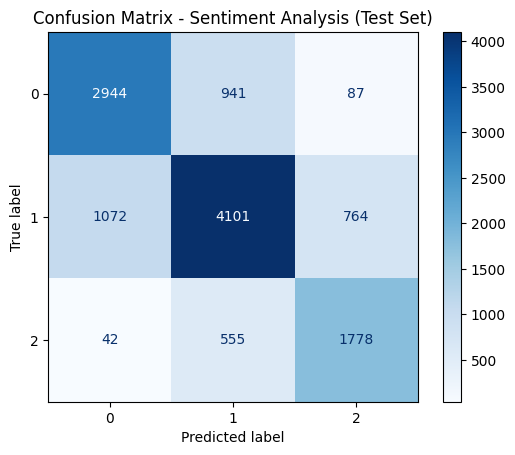

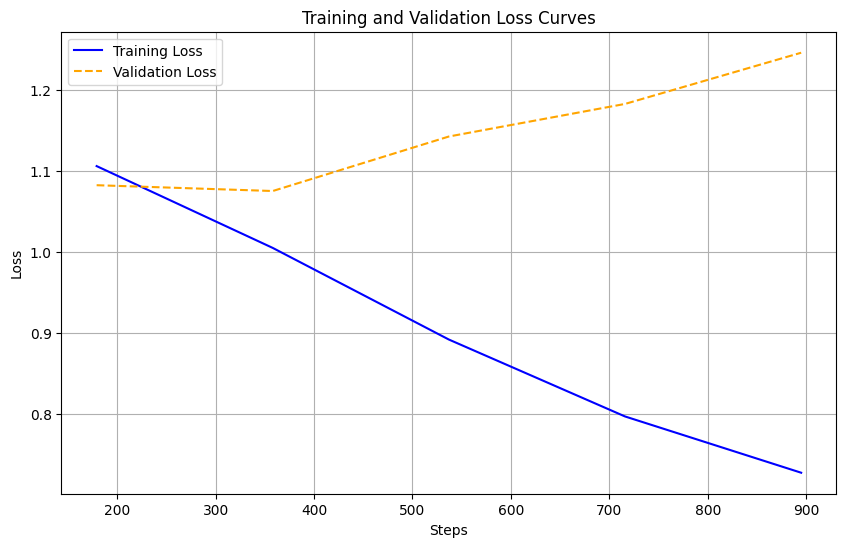

In [26]:
predictions_object = trainer.predict(senti_test_ds)
print(predictions_object.metrics)

senti_metrics_evaluation(predictions_object)

### 6.4 Save Model & Archive

The fine-tuned model weights and tokeniser config are saved locally, then zipped for portability.  
The archive can be re-loaded with `AutoModelForSequenceClassification.from_pretrained("./sentiment_model")`.


In [39]:
trainer.save_model("./sentiment_model")
tokenizer.save_pretrained("./sentiment_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./sentiment_model/tokenizer_config.json', './sentiment_model/tokenizer.json')

In [40]:
import shutil
shutil.make_archive("sentiment_model", "zip", "./sentiment_model")

'/kaggle/working/sentiment_model.zip'

## 7. Memory Cleanup

Running two separate RoBERTa-base models simultaneously may cause an out-of-memory (OOM) error. Before loading the hate model, the sentiment model and trainer are explicitly deleted, Python's garbage collector is invoked, and the CUDA cache is cleared.


In [ ]:
del senti_model
if 'trainer' in locals(): 
    del trainer
gc.collect()
torch.cuda.empty_cache()

## 8. Hate Speech Model — Fine-tuning

The hate speech model follows the same training pipeline as the sentiment model, with these differences:

- **Checkpoint:** `cardiffnlp/twitter-roberta-base-hate-latest` — pre-trained on hate speech data specifically.
- **`num_labels=2`** — binary classification (non-hate / hate).
- **`HATE_EPOCHS=3`** — fewer epochs; the binary task converges faster than the 3-class sentiment task.
- **Output dir:** `./results/hate`

### 8.1 Tokeniser & Dataset Objects


In [20]:
tokenizer = AutoTokenizer.from_pretrained(HATE_MODEL_NAME)

config.json:   0%|          | 0.00/888 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/351 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/280 [00:00<?, ?B/s]

In [22]:
hate_train_ds = TweetDataset(hate_train['clean_text'], hate_train['label'], tokenizer, MAX_LENGTH)
hate_val_ds = TweetDataset(hate_val['clean_text'], hate_val['label'], tokenizer, MAX_LENGTH)
hate_test_ds = TweetDataset(hate_test['clean_text'], hate_test['label'], tokenizer, MAX_LENGTH)

### 8.2 Load Pretrained Model


In [23]:
# Load the model configuration and architecture
hate_model = AutoModelForSequenceClassification.from_pretrained(HATE_MODEL_NAME, num_labels = 2)

# Move all model weights and parameters to the chosen device memory
hate_model = hate_model.to(DEVICE)

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-hate-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

### 8.3 Compute Warm-up Steps


In [28]:
TOTAL_STEPS = (len(hate_train_ds) // BATCH_SIZE) * HATE_EPOCHS
WARMUP_STEPS = int(TOTAL_STEPS * WARMUP_RATIO)

print(f"Total steps: {TOTAL_STEPS}, Warmup steps: {WARMUP_STEPS}")

Total steps: 210, Warmup steps: 12


### 8.4 Training Arguments


In [29]:
training_args = TrainingArguments(
    output_dir = "./results/hate",
    num_train_epochs = HATE_EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size = BATCH_SIZE,
    learning_rate = LR,
    warmup_steps = WARMUP_STEPS,
    weight_decay = WEIGHT_DECAY,
    eval_strategy = "epoch",
    logging_steps = 1,
    logging_strategy="epoch",
    save_strategy = "epoch",
    load_best_model_at_end = True,
    metric_for_best_model = "macro_f1",
    seed = SEED,
)

### 8.5 Initialise Trainer & Run Training


In [30]:
trainer = Trainer(
    model = hate_model,
    args = training_args,
    train_dataset = hate_train_ds,
    eval_dataset = hate_val_ds,
    compute_metrics = compute_metrics
)

In [31]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Macro F1
1,0.758282,0.771512,0.842358
2,0.525866,0.820614,0.845858
3,0.441793,0.806329,0.853558


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=108, training_loss=0.5753137800428603, metrics={'train_runtime': 313.9798, 'train_samples_per_second': 85.926, 'train_steps_per_second': 0.344, 'total_flos': 1774618290639360.0, 'train_loss': 0.5753137800428603, 'epoch': 3.0})

## 9. Hate Speech Model — Evaluation & Saving

### 9.1 Evaluation Wrapper


In [32]:
def hate_metrics_evaluation(preds_obj):
    logits = preds_obj.predictions
    labels = preds_obj.label_ids
    # logits, labels, _ = preds_obj
    pred_classes = np.argmax(logits, axis=-1)

    print_model_evaluation("Hate Detection", labels, pred_classes)
    plot_confusion_matrix("Hate Detection", labels, pred_classes)
    plot_training_curve()

### 9.2 Predict on Test Set & Report Results


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'test_loss': 1.9660766124725342, 'test_macro_f1': 0.650803172628892, 'test_runtime': 12.645, 'test_samples_per_second': 234.876, 'test_steps_per_second': 0.949}

 EVALUATION REPORT: HATE DETECTION 

🔸TEST SET PERFORMANCE
Accuracy: 0.6603 (66.03%)
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.96      0.43      0.59      1718
           1       0.56      0.98      0.71      1252

    accuracy                           0.66      2970
   macro avg       0.76      0.70      0.65      2970
weighted avg       0.79      0.66      0.64      2970



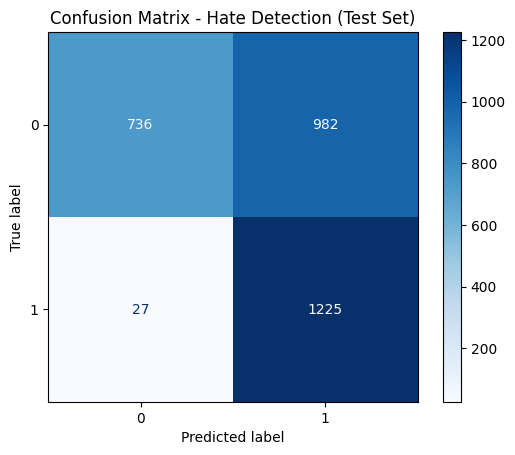

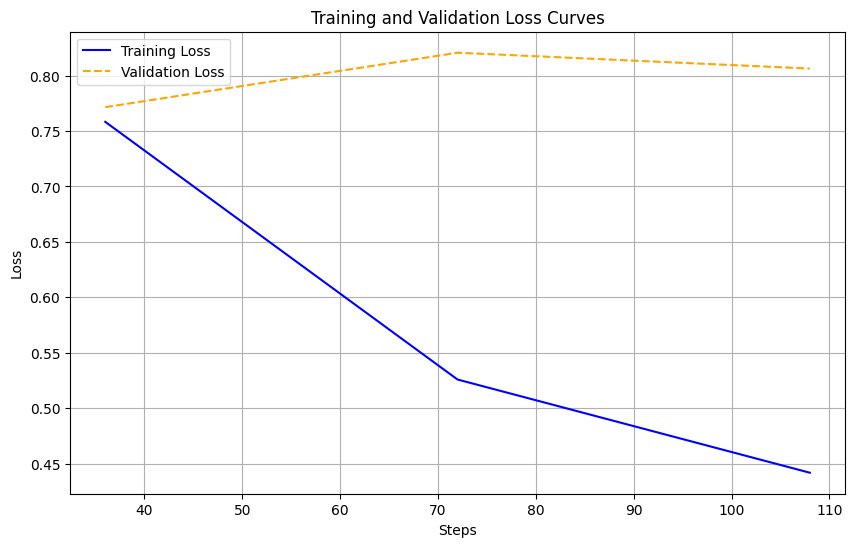

In [33]:
predictions_object = trainer.predict(hate_test_ds)
print(predictions_object.metrics)

hate_metrics_evaluation(predictions_object)

### 9.3 Val vs. Test Distribution Check

A brief sanity check comparing the label distribution of the validation and test splits.  
This is relevant context for interpreting any gap between val and test performance — a distribution shift here could explain diverging metrics.


In [44]:
# Example with matching class labels
df1 = pd.DataFrame(hate_val['label'])
df2 = pd.DataFrame(hate_test['label'])

# Combine distributions into a single view
comparison_df = pd.DataFrame(
    {
        "Val Distribution": df1["label"].value_counts(),
        "Test Distribution": df2["label"].value_counts(),
    }
)
print(comparison_df)

       Val Distribution  Test Distribution
label                                     
0                   572               1718
1                   427               1252


### 9.4 Validation Set Evaluation (Sanity Check)

Running the evaluation wrapper on the **validation set** as an additional sanity check.  
Val performance should be close to what the `Trainer` logged per epoch. Large gaps between val and test results signal distribution shift.

> For official reporting, **test set numbers are used exclusively**.


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'test_loss': 0.8063288927078247, 'test_macro_f1': 0.8535583042262919, 'test_runtime': 4.08, 'test_samples_per_second': 244.853, 'test_steps_per_second': 0.98}

 EVALUATION REPORT: HATE DETECTION 

🔸TEST SET PERFORMANCE
Accuracy: 0.8549 (85.49%)
------------------------------------------------------------
              precision    recall  f1-score   support

           0       0.91      0.83      0.87       572
           1       0.79      0.89      0.84       427

    accuracy                           0.85       999
   macro avg       0.85      0.86      0.85       999
weighted avg       0.86      0.85      0.86       999



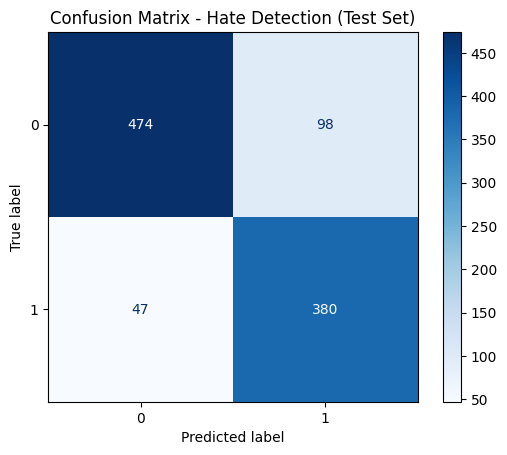

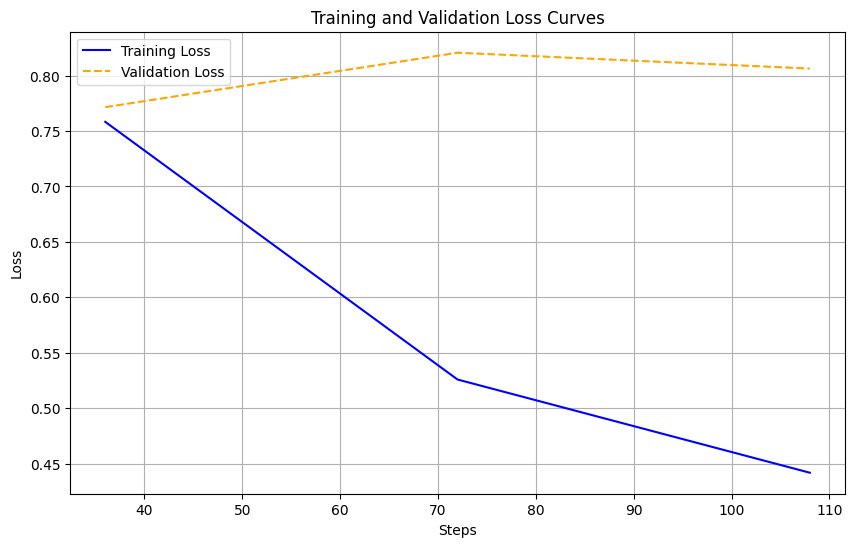

In [46]:
val_preds = trainer.predict(hate_val_ds)
print(val_preds.metrics)

hate_metrics_evaluation(val_preds)

### 9.5 Save Model & Archive


In [47]:
trainer.save_model("./hate_model")
tokenizer.save_pretrained("./hate_model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('./hate_model/tokenizer_config.json', './hate_model/tokenizer.json')

In [48]:
import shutil
shutil.make_archive("hate_model", "zip", "./hate_model")

'/kaggle/working/hate_model.zip'

## 10. E1 vs E2 — Comparative Results Table

The DataFrame below summarises E1 (TF-IDF + Logistic Regression) and E2 (RoBERTa fine-tuning) side-by-side on the **test set**, across all four reported metrics.


In [7]:
# Define the dataset from your provided metrics
data = {
    "Model": [
        "TF-IDF + Logistic Regression (E1)",
        "TF-IDF + Logistic Regression (E1)",
        "RoBERTa (E2)",
        "RoBERTa (E2)"
    ],
    "Task": ["Sentiment", "Hate", "Sentiment", "Hate"],
    "Accuracy": ["0.5916 (59.16%)", "0.4896 (48.96%)", "0.7183 (71.83%)", "0.6603 (66.03%)"],
    "Precision": [0.60, 0.59, 0.71, 0.76],
    "Recall": [0.57, 0.55, 0.73, 0.70],
    "F1": [0.56, 0.45, 0.718, 0.651]
}

# Create the DataFrame
df = pd.DataFrame(data)

# Display the final DataFrame
df

,Model,Task,Accuracy,Precision,Recall,F1
0,TF-IDF + Logistic Regression (E1),Sentiment,0.5916 (59.16%),0.60,0.57,0.560
1,TF-IDF + Logistic Regression (E1),Hate,0.4896 (48.96%),0.59,0.55,0.450
2,RoBERTa (E2),Sentiment,0.7183 (71.83%),0.71,0.73,0.718
3,RoBERTa (E2),Hate,0.6603 (66.03%),0.76,0.70,0.651


## Conclusion

### Results Summary (Test Set)

| Model | Task | Accuracy | Macro-F1 |
|---|---|---|---|
| TF-IDF + LR (E1) | Sentiment | 0.5916 | 0.56 |
| **RoBERTa (E2)** | **Sentiment** | **0.7183** | **0.718** |
| TF-IDF + LR (E1) | Hate Speech | 0.4896 | 0.45 |
| **RoBERTa (E2)** | **Hate Speech** | **0.6603** | **0.651** |

### Key Observations

**Sentiment Analysis:**
- RoBERTa improves accuracy by **+12.7 pp** (0.5916 → 0.7183) and macro-F1 by **+15.8 pp** (0.56 → 0.718).
- The dominant source of E1's underperformance was the negative class (E1 F1 = 0.44). The RoBERTa checkpoint, pre-trained on Twitter data, has internalised contextual cues — negation, sarcasm, hedging — that TF-IDF bag-of-words representations cannot encode.
- The E1 val→test macro-F1 drop (0.63 → 0.56) caused by the sentiment test distribution shift is partially absorbed by RoBERTa's more robust representations.

**Hate Speech Detection:**
- RoBERTa improves accuracy by **+17.1 pp** (0.4896 → 0.6603) and macro-F1 by **+20.1 pp** (0.45 → 0.651).
- The E1 hate collapse (macro-F1 = 0.45, non-hate recall = 0.19) was attributed to TF-IDF's inability to distinguish hate-adjacent vocabulary used in counter-speech from genuine hate speech. RoBERTa's attention mechanism resolves this by modelling full sentence context, dramatically recovering non-hate precision and recall.
- `twitter-roberta-base-hate-latest` is further specialised for hate detection, giving it domain-specific prior knowledge that accelerates convergence.

### Limitations

1. **Sentiment test distribution shift** — the test split has more negative tweets (~32%) than training (~16%). Both E1 and E2 are affected; the limitation is a TweetEval benchmark artefact, not a model fault.
2. **Hate tweet truncation** — a minority of hate tweets exceed 128 tokens and are truncated. Impact is expected to be small but is documented.
3. **VRAM constraint** — batch size 128 at max_length 128 is close to the RTX 2050's 4 GB limit. Models were trained sequentially (not simultaneously) as a mitigation.

### Forward Look — E3

The negative-class recall weakness in sentiment persists even after fine-tuning (though improved). **E3** applies weighted loss to further target this gap, increasing the training loss penalty for minority-class misclassifications.
